# Predicting Diabetes from Pima Indians dataset


In [3]:
import pandas as pd
pd.set_option('display.max_columns',100)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

plt.style.use('seaborn-v0_8-whitegrid')
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("diabetes.csv")
print("Raw data shape:",df.shape)
df.head()

Raw data shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [7]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [8]:
print("Target class distribution:")
print(df['Outcome'].value_counts())
print("-"*20)
print(f"Not Diabetic (0): {df['Outcome'].value_counts()[0]} ({df['Outcome'].value_counts()[0]/len(df)*100:.1f}%)")
print(f"Diabetic     (1): {df['Outcome'].value_counts()[1]} ({df['Outcome'].value_counts()[1]/len(df)*100:.1f}%)")

Target class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64
--------------------
Not Diabetic (0): 500 (65.1%)
Diabetic     (1): 268 (34.9%)


Text(0.5, 1.0, 'Percentage Split')

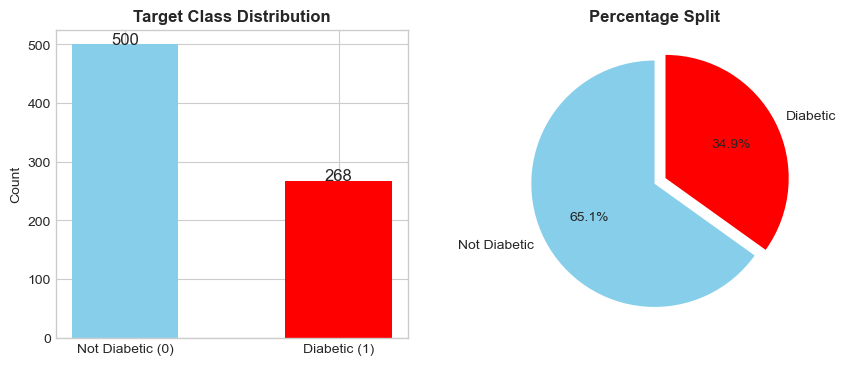

In [9]:
fig,axes = plt.subplots(1,2,figsize = (10,4))
counts = df["Outcome"].value_counts()
axes[0].bar(['Not Diabetic (0)', 'Diabetic (1)'], counts.values, color = ['skyblue','red'], width = 0.5)
axes[0].set_title('Target Class Distribution', fontweight = 'bold')
axes[0].set_ylabel('Count')
for i,v in enumerate(counts.values):
    axes[0].text(i,v,str(v), ha= 'center',fontsize = 12)

axes[1].pie(counts.values, labels = ['Not Diabetic', 'Diabetic'],colors = ['skyblue','red'], autopct = "%1.1f%%", startangle = 90, explode = (0,0.1))
axes[1].set_title("Percentage Split", fontweight = 'bold')

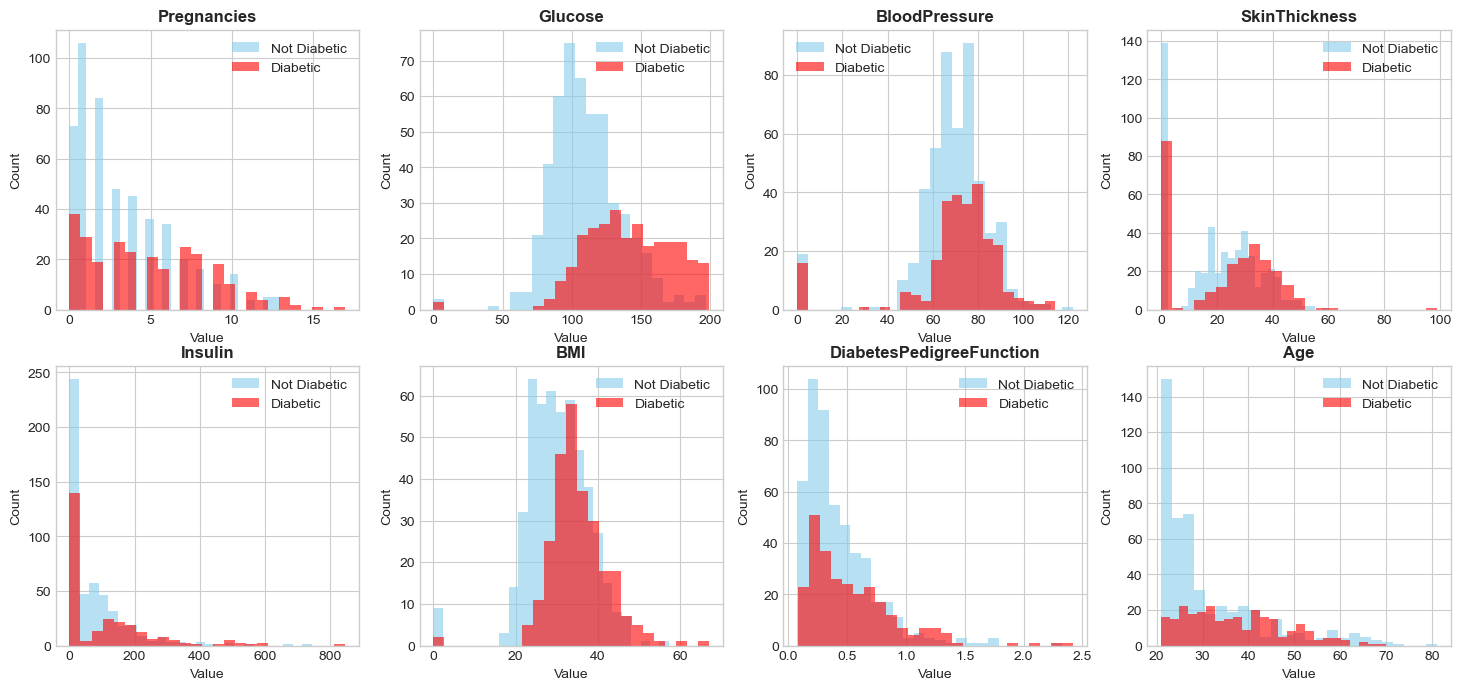

In [10]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',	'Insulin',	
            'BMI', 'DiabetesPedigreeFunction', 'Age']
fig, axes = plt.subplots(2,4,figsize=(18,8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[df['Outcome']==0][col], bins = 25, alpha = 0.6, label='Not Diabetic', color = 'skyblue')
    axes[i].hist(df[df['Outcome']==1][col], bins = 25, alpha = 0.6, label='Diabetic', color = 'red')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend()

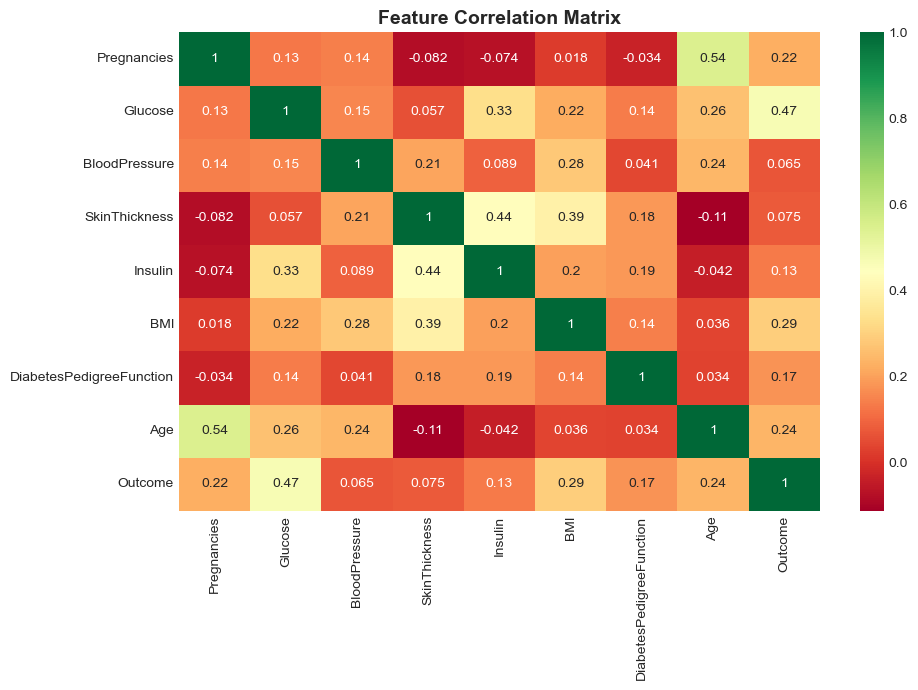

In [11]:
plt.figure(figsize = (10,7))
corr = df.corr()
sns.heatmap(corr, annot = True, cmap = 'RdYlGn')
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

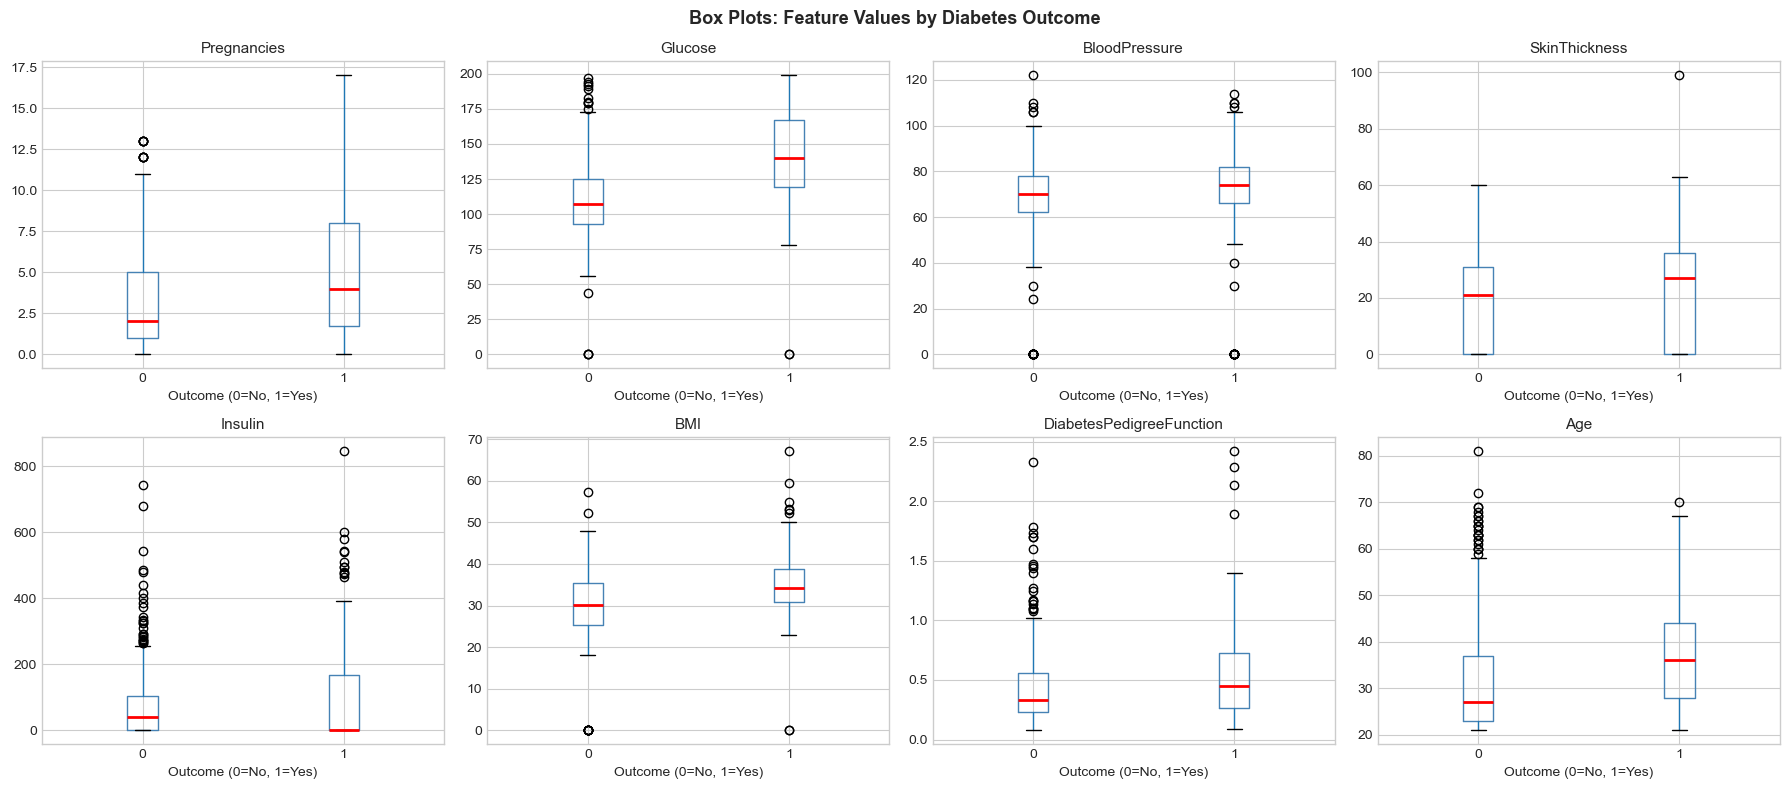

In [12]:
fig,axes = plt.subplots(2,4, figsize = (18,8))
axes = axes.flatten()
for i,col in enumerate(features):
    df.boxplot(column=col, by='Outcome', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Outcome (0=No, 1=Yes)')
plt.suptitle('Box Plots: Feature Values by Diabetes Outcome', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
#Data Cleaning
df_clean = df.copy()
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print('Zero value counts BEFORE Cleaning:')
for col in zero_cols:
    n = (df_clean[col]==0).sum()
    print(f'{col}:  {n} zeros')
for col in zero_cols:
    df_clean[col] = df_clean[col].replace(0,np.nan)
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
print("-"*20)
print('Zero value counts AFTER Cleaning:')
for col in zero_cols:
    print(f'{col}:  {(df_clean[col] == 0).sum()} zeros')

Zero value counts BEFORE Cleaning:
Glucose:  5 zeros
BloodPressure:  35 zeros
SkinThickness:  227 zeros
Insulin:  374 zeros
BMI:  11 zeros
--------------------
Zero value counts AFTER Cleaning:
Glucose:  0 zeros
BloodPressure:  0 zeros
SkinThickness:  0 zeros
Insulin:  0 zeros
BMI:  0 zeros


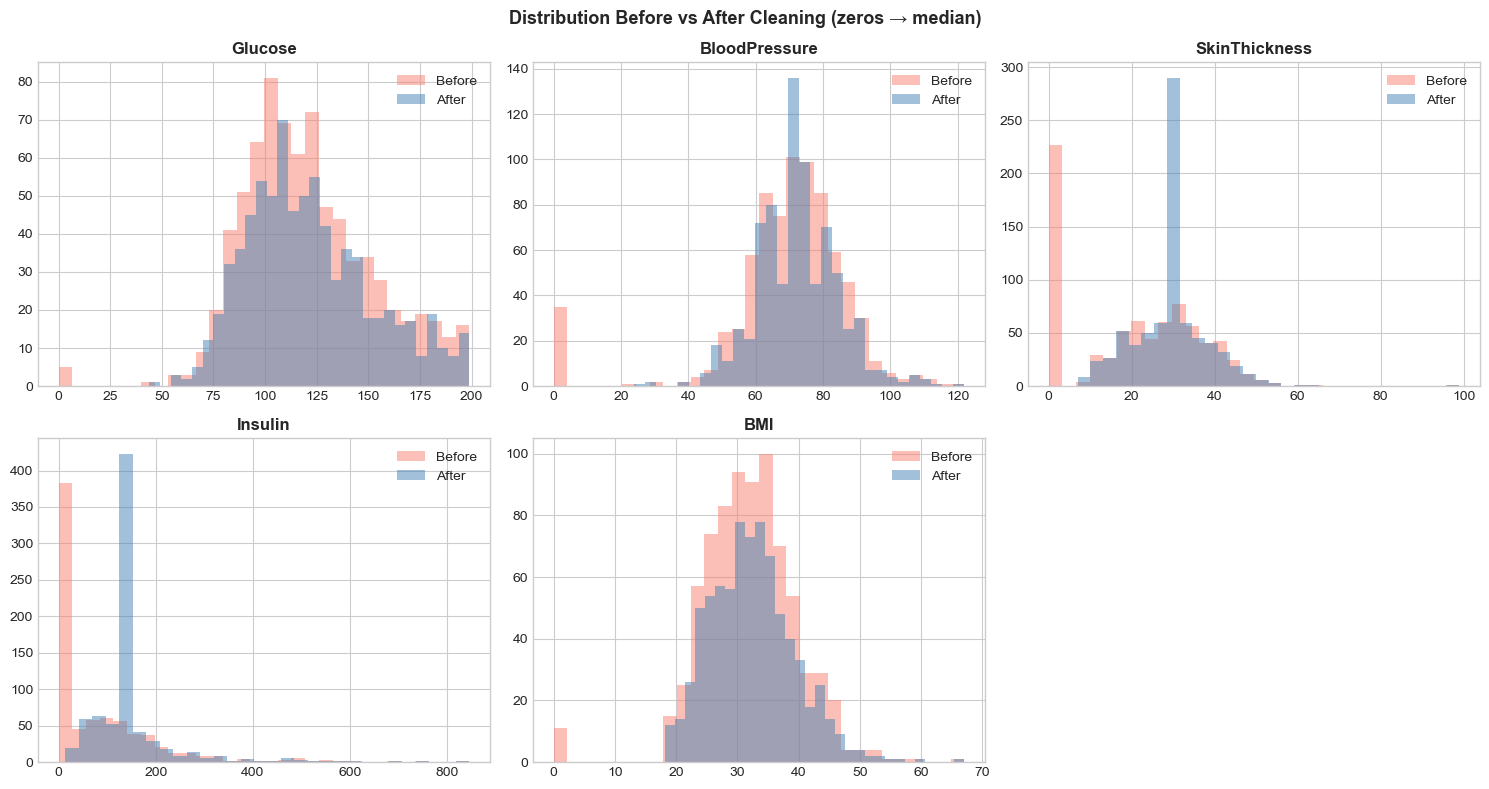

In [14]:
fig, axes = plt.subplots(2,3, figsize=(15,8))
for i,col in enumerate(zero_cols):
    row, c = divmod(i,3)
    axes[row][c].hist(df[col], bins=30, alpha=0.5, label='Before', color='salmon')
    axes[row][c].hist(df_clean[col], bins=30, alpha=0.5, label='After', color='steelblue')
    axes[row][c].set_title(f'{col}', fontweight='bold')
    axes[row][c].legend()
axes[1][2].axis('off')
plt.suptitle('Distribution Before vs After Cleaning (zeros → median)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
df_feat = df_clean.copy()
#New feature: BMI Category 0=Underweight, 1=Normal, 2=Overweight, 3=Obese
df_feat['BMI_Category']=pd.cut(df_feat['BMI'],bins = [0,18.5,25,30,100],
                              labels = [0,1,2,3]) 
df_feat['BMI_Category']=df_feat['BMI_Category'].astype(int)
#New feature: Age group 0:<=30, 1:=30-45, 2:45-60, 3:60+
df_feat['Age_Group']=pd.cut(df_feat['Age'],bins = [0,30,45,60,100],
                              labels = [0,1,2,3]) #Young,Middle,Senior,Elderly
df_feat['Age_Group']=df_feat['Age_Group'].astype(int)
#New feature: Glucose x BMI interaction
df_feat['Glucose_BMI'] = df_feat['Glucose'] * df_feat['BMI'] / 100
df_feat[['BMI', 'BMI_Category', 'Age', 'Age_Group', 'Glucose', 'Glucose_BMI']].head()

,BMI,BMI_Category,Age,Age_Group,Glucose,Glucose_BMI
0,33.6,3,50,2,148.0,49.728
1,26.6,2,31,1,85.0,22.610
2,23.3,1,32,1,183.0,42.639
3,28.1,2,21,0,89.0,25.009
4,43.1,3,33,1,137.0,59.047


In [16]:
#define feature X and target y
X = df_feat.drop('Outcome', axis = 1)
y = df_feat['Outcome']
print("Features used for training:")
for col in enumerate(X.columns, 1):
    print(col)
    
#Train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)
print(f'\nTrain set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')

#Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Features used for training:
(1, 'Pregnancies')
(2, 'Glucose')
(3, 'BloodPressure')
(4, 'SkinThickness')
(5, 'Insulin')
(6, 'BMI')
(7, 'DiabetesPedigreeFunction')
(8, 'Age')
(9, 'BMI_Category')
(10, 'Age_Group')
(11, 'Glucose_BMI')

Train set: 614 samples
Test set: 154 samples


## — Train Multiple Models

**6 different algorithms** and compare their performance.

| Model | Type | Notes |
|---|---|---|
| Logistic Regression | Linear | Fast, interpretable |
| Decision Tree | Tree | Interpretable, prone to overfitting |
| Random Forest | Ensemble | More robust than single tree |
| Gradient Boosting | Ensemble | Often best performance |

In [17]:
#define models
models = {
    'Logistic Regession': LogisticRegression(C=1,max_iter=1000, class_weight='balanced', random_state = 42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

#Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle= True, random_state=42)
results = {}
print("Training models with 5-Fold Cross Validation:")
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train,
                             cv=5, scoring='roc_auc')  # ROC-AUC is better than accuracy for imbalanced data
    results[name] = scores
    print(f'  {name:<25} ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}')

Training models with 5-Fold Cross Validation:
  Logistic Regession        ROC-AUC: 0.8416 ± 0.0245
  Decision Tree             ROC-AUC: 0.7430 ± 0.0192
  Random Forest             ROC-AUC: 0.8199 ± 0.0204
  Gradient Boosting         ROC-AUC: 0.8180 ± 0.0236


In [32]:
#Evaluate all models on the TEST set
test_results = {} 
for name, model in models.items():
    model.fit(X_train_scaled, y_train) # train on the full training data
    #predict on the test data
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:,1]
    #compute metrics
    acc = accuracy_score(y_test,y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    test_results[name] = {
        'accuracy':  acc,
        'roc_auc':   roc_auc,
        'y_pred':    y_pred,
        'y_proba':   y_proba
    }
    
    print()
    print(f"Name model: {name}")
    print("-"*40)
    print(f"Accuracy: {acc:.4f} ({acc*100:.1f}%)")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=['Not Diabetic', 'Diabetic']))
    print("**"*40)


Name model: Logistic Regession
----------------------------------------
Accuracy: 0.7338 (73.4%)
ROC-AUC: 0.8243

              precision    recall  f1-score   support

Not Diabetic       0.83      0.74      0.78       100
    Diabetic       0.60      0.72      0.66        54

    accuracy                           0.73       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154

********************************************************************************

Name model: Decision Tree
----------------------------------------
Accuracy: 0.6753 (67.5%)
ROC-AUC: 0.7206

              precision    recall  f1-score   support

Not Diabetic       0.71      0.84      0.77       100
    Diabetic       0.56      0.37      0.44        54

    accuracy                           0.68       154
   macro avg       0.63      0.61      0.61       154
weighted avg       0.66      0.68      0.66       154

****************************************

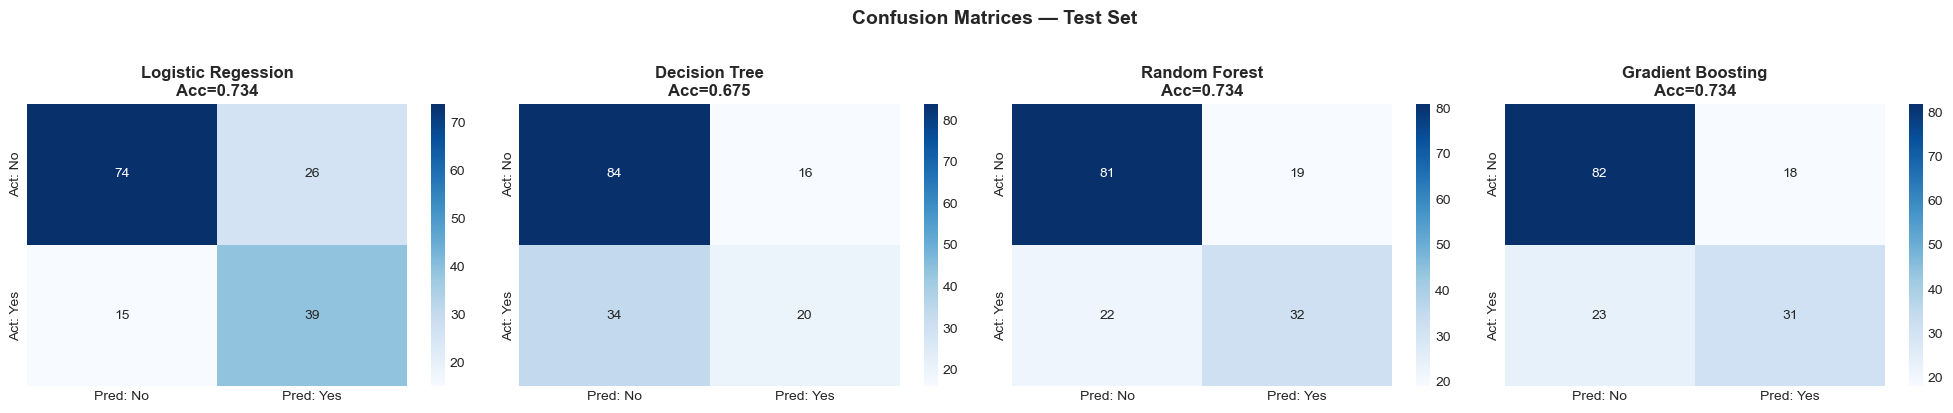

In [38]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, res) in zip(axes, test_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: No', 'Pred: Yes'],
                yticklabels=['Act: No',  'Act: Yes'])
    ax.set_title(f'{name}\nAcc={res["accuracy"]:.3f}', fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

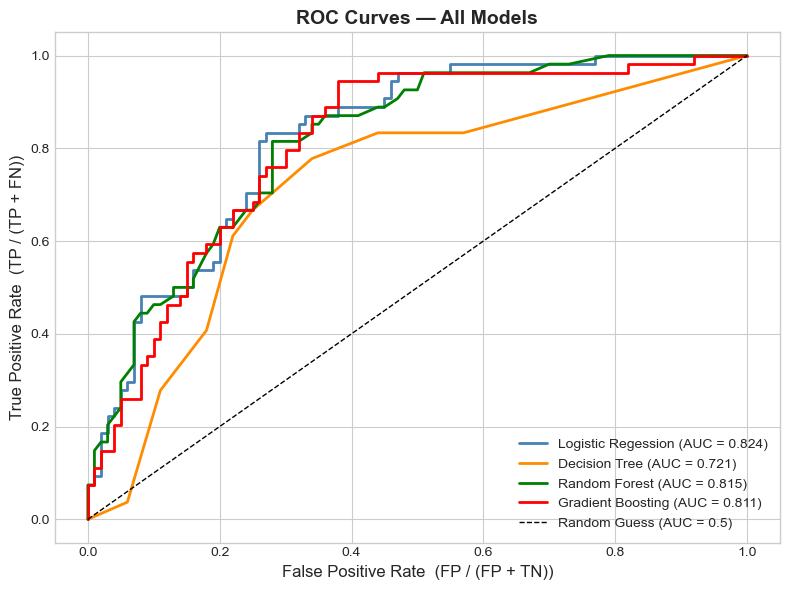


🏆  Best model by ROC-AUC: Logistic Regession  (AUC = 0.8243)


In [48]:
plt.figure(figsize = (8,6))
colors = ['steelblue', 'darkorange', 'green', 'red']
for (name, res), color in zip(test_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['roc_auc']:.3f})", color=color, lw=2)

# Diagonal = random guessing baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)', lw=1)

plt.xlabel('False Positive Rate  (FP / (FP + TN))', fontsize=12)
plt.ylabel('True Positive Rate  (TP / (TP + FN))', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
best_model_name = max(test_results, key=lambda m: test_results[m]['roc_auc'])
print(f"\n🏆  Best model by ROC-AUC: {best_model_name}  "
      f"(AUC = {test_results[best_model_name]['roc_auc']:.4f})")

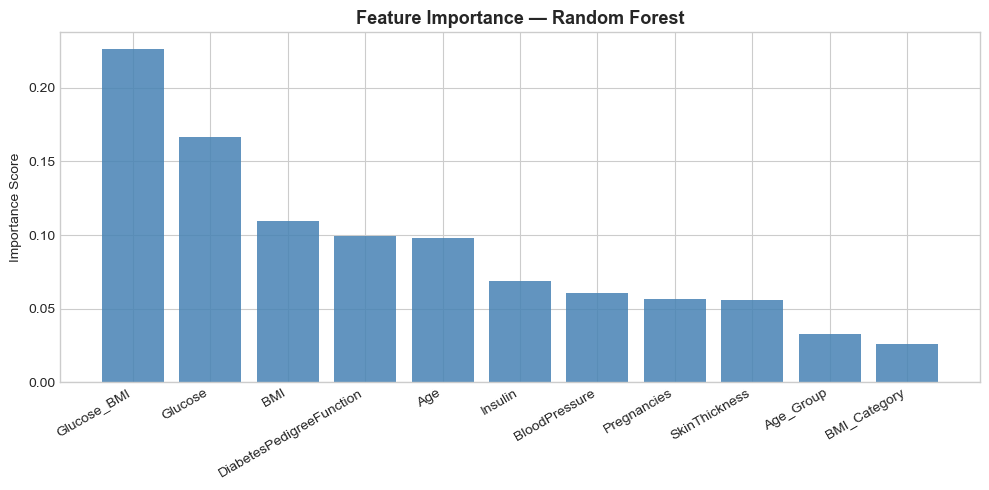

Feature ranking:
  1. Glucose_BMI                    0.2264
  2. Glucose                        0.1663
  3. BMI                            0.1094
  4. DiabetesPedigreeFunction       0.0995
  5. Age                            0.0977
  6. Insulin                        0.0689
  7. BloodPressure                  0.0607
  8. Pregnancies                    0.0563
  9. SkinThickness                  0.0561
  10. Age_Group                      0.0328
  11. BMI_Category                   0.0259


In [49]:
rf_model = models['Random Forest']   # already trained above

importances = rf_model.feature_importances_
feature_names = X.columns.tolist()

# Sort from most to least important
sorted_idx = importances.argsort()[::-1]
plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_names)),
        importances[sorted_idx],
        color='steelblue', alpha=0.85)
plt.xticks(range(len(feature_names)),
           [feature_names[i] for i in sorted_idx],
           rotation=30, ha='right')
plt.ylabel('Importance Score')
plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Feature ranking:")
for rank, idx in enumerate(sorted_idx, 1):
    print(f"  {rank}. {feature_names[idx]:<30} {importances[idx]:.4f}")

In [53]:
# ── Predict on a New Patient ─────────────────────────────────────────────────
# This is the fun part!  Let's use our best model to predict whether
# a made-up patient has diabetes.

# --- Fill in any values you like ---
new_patient = {
    'Pregnancies': 4,
    'Glucose': 145,
    'BloodPressure': 78,
    'SkinThickness': 32,
    'Insulin': 130,
    'BMI': 34.5,
    'DiabetesPedigreeFunction': 0.45,
    'Age': 50
}

# --- Derive the same engineered features we added earlier ---
bmi = new_patient['BMI']
age = new_patient['Age']
glucose = new_patient['Glucose']

import pandas as pd
import numpy as np

# BMI Category
if   bmi < 18.5: bmi_cat = 0
elif bmi < 25:   bmi_cat = 1
elif bmi < 30:   bmi_cat = 2
else:            bmi_cat = 3

# Age Group
if   age <= 30:  age_grp = 0
elif age <= 45:  age_grp = 1
elif age <= 60:  age_grp = 2
else:            age_grp = 3

new_patient['BMI_Category'] = bmi_cat
new_patient['Age_Group']    = age_grp
new_patient['Glucose_BMI']  = glucose * bmi / 100

# Convert to DataFrame so column order matches training data
new_df = pd.DataFrame([new_patient])[X.columns]

# Scale using the SAME scaler fitted on training data
new_scaled = scaler.transform(new_df)

# --- Predict using the best model ---
best_model = models[best_model_name]
prediction  = best_model.predict(new_scaled)[0]
probability = best_model.predict_proba(new_scaled)[0][1]

print("  DIABETES PREDICTION FOR NEW PATIENT")
print("=" * 45)
print(f"  Model used      : {best_model_name}")
print(f"  Prediction      : {'DIABETIC' if prediction == 1 else 'NOT Diabetic'}")
print(f"  Probability     : {probability:.1%} chance of diabetes")
print("=" * 45)
print("\n  Input values:")
for k, v in new_patient.items():
    print(f"    {k:<30} {v}")


  DIABETES PREDICTION FOR NEW PATIENT
  Model used      : Logistic Regession
  Prediction      : DIABETIC
  Probability     : 80.5% chance of diabetes

  Input values:
    Pregnancies                    4
    Glucose                        145
    BloodPressure                  78
    SkinThickness                  32
    Insulin                        130
    BMI                            34.5
    DiabetesPedigreeFunction       0.45
    Age                            50
    BMI_Category                   3
    Age_Group                      2
    Glucose_BMI                    50.025
